In [3]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv('StudentsPerformance.csv')

ЭТАП 1: Анализ данных (EDA)

In [5]:
# 1.	Загрузить датасет (из Kaggle или другого источника) и вывести первые 10 строк.
df.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [6]:
#2.	Посмотреть .info(), .shape, .describe().
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
df.shape

(1000, 8)

In [8]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [9]:
# 3.	Вывести список колонок и их типы.
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


In [10]:
#4.	Проверить на пропущенные значения.
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [11]:
#5.	Сохранить очищенный датафрейм в students_clean.csv.
df.to_csv('students_clean.csv', index=False)

In [12]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [13]:
#6.	Сколько уникальных значений у race/ethnicity?
df['race/ethnicity'].nunique()

5

In [14]:
#7.	Топ-3 самых высоких средних оценок по математике среди этнических групп.

df.groupby('race/ethnicity')['math score'].mean().sort_values(ascending=False).head(3).round(2)

,math score
race/ethnicity,
group E,73.82
group D,67.36
group C,64.46


In [15]:
#8.	Сколько учеников прошли курс подготовки (test preparation course)?
(df['test preparation course'] == 'completed').sum()

np.int64(358)

In [16]:
#9.	Средняя оценка по математике среди тех, кто прошел курс.
df.groupby('test preparation course')['math score'].mean().round(2)

,math score
test preparation course,
completed,69.70
none,64.08


In [17]:
#10.	Средняя оценка по чтению среди учеников с бесплатным питанием (lunch == free/reduced).
lunch_free = df[df['lunch'] == 'free/reduced']
lunch_free.groupby('lunch')['reading score'].mean().round()

,reading score
lunch,
free/reduced,65.0


In [18]:
#11.	Сколько учеников с уровнем образования родителей bachelor's degree?

(df['parental level of education'] == "bachelor's degree").sum()

np.int64(118)

In [19]:
#14.	Средний балл по математике по уровню образования родителей.

df.groupby('parental level of education')['math score'].mean().round().sort_values(ascending=False)

,math score
parental level of education,
master's degree,70.0
bachelor's degree,69.0
associate's degree,68.0
some college,67.0
some high school,63.0
high school,62.0


In [20]:
#17.    У скольких учеников math score >= 90?

(df['math score'] >= 90).sum()

np.int64(58)

In [21]:
#20.	Создать новый столбец average_score = среднее из трех оценок.

df['avarage_score'] = ((df['math score'] + df['reading score'] + df['writing score'])/3).round(2)

In [22]:
# 12.	Средние баллы по всем предметам по полу (gender).
df.groupby('gender')[['math score','reading score','writing score']].mean().round(2)

,math score,reading score,writing score
gender,,,
female,63.63,72.61,72.47
male,68.73,65.47,63.31


In [23]:
# 13.	У кого медианная оценка по письму выше — мужчины или женщины?
df.groupby('gender')['writing score'].median().round(2)

,writing score
gender,
female,74.0
male,64.0


In [24]:
# 15.	Группировка по test preparation course и lunch + средние оценки.
df.groupby(['test preparation course','lunch'])[['math score','reading score','writing score']].mean().round(2)

math score  reading score  writing score
test preparation course lunch                                                 
completed               free/reduced       63.05          69.87          70.35
                        standard           73.53          76.22          76.77
none                    free/reduced       56.51          61.60          58.74
                        standard           68.13          69.18          67.60

In [25]:
# 16.	Найти самого успешного ученика (максимум по сумме 3 оценок).
df['3 subjects'] = df['math score'] + df['reading score'] + df['writing score']

In [26]:
df[df['3 subjects'] == 300]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,avarage_score,3 subjects
458,female,group E,bachelor's degree,standard,none,100,100,100,100.0,300
916,male,group E,bachelor's degree,standard,completed,100,100,100,100.0,300
962,female,group E,associate's degree,standard,none,100,100,100,100.0,300


In [27]:
# 18.	У скольких учеников все три оценки больше 80?

(df['3 subjects'] >= 80).sum()

np.int64(994)

In [28]:
# 19.	Группировка по gender, race/ethnicity, mean().
df.groupby(['gender','race/ethnicity'])[['math score','reading score','writing score']].mean().round(2)

math score  reading score  writing score
gender race/ethnicity                                          
female group A              58.53          69.00          67.86
       group B              61.40          71.08          70.05
       group C              62.03          71.94          71.78
       group D              65.25          74.05          75.02
       group E              70.81          75.84          75.54
male   group A              63.74          61.74          59.15
       group B              65.93          62.85          60.22
       group C              67.61          65.42          62.71
       group D              69.41          66.14          65.41
       group E              76.75          70.30          67.39

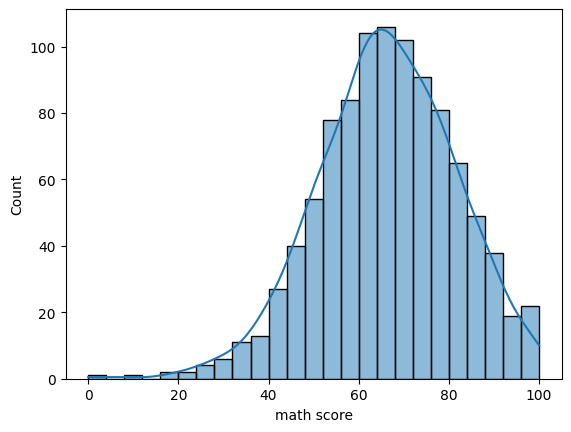

In [29]:
# 41.	Построить histplot для math score.
sns.histplot(data=df, x ='math score', kde=True)
plt.show()

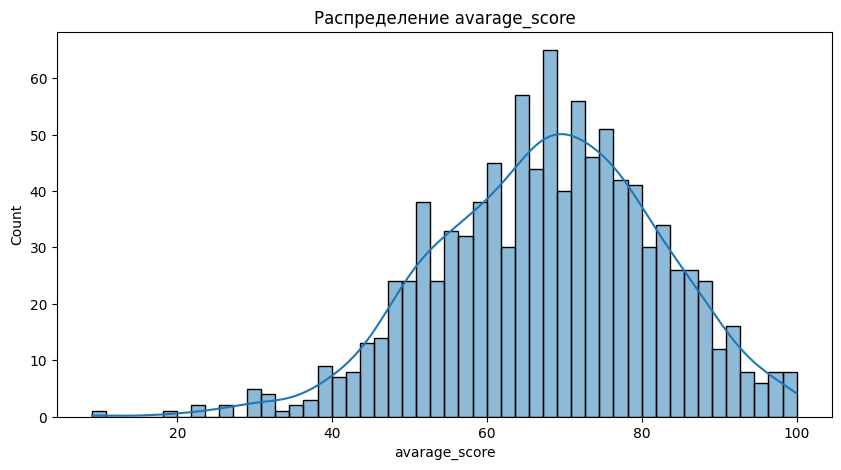

In [30]:
# 42.	Распределение average_score.
plt.figure(figsize=(10,5))
sns.histplot(data=df, x ='avarage_score', kde=True, bins=50)
plt.title('Распределение avarage_score')
plt.savefig('avarage_score.png')
plt.show()

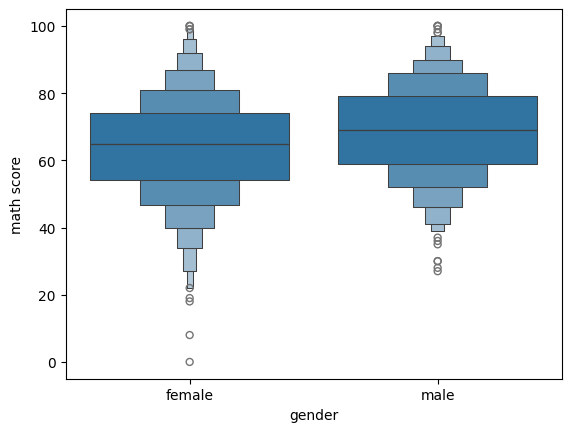

In [31]:
# 43.	boxplot: gender vs math score.
sns.boxenplot(data=df, x='gender', y='math score')
plt.show()

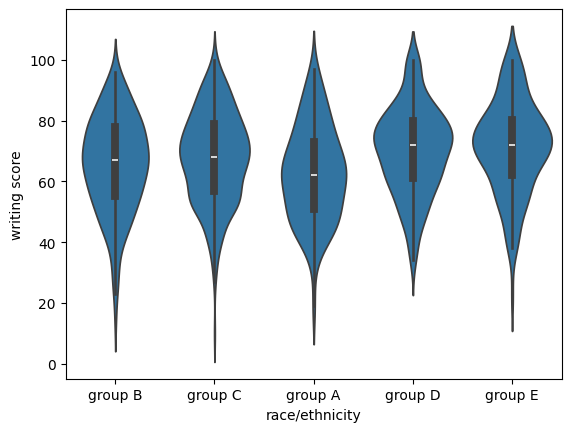

In [32]:
# 44.	violinplot: race/ethnicity vs writing score.
sns.violinplot(data=df, x='race/ethnicity' , y='writing score')
plt.show()

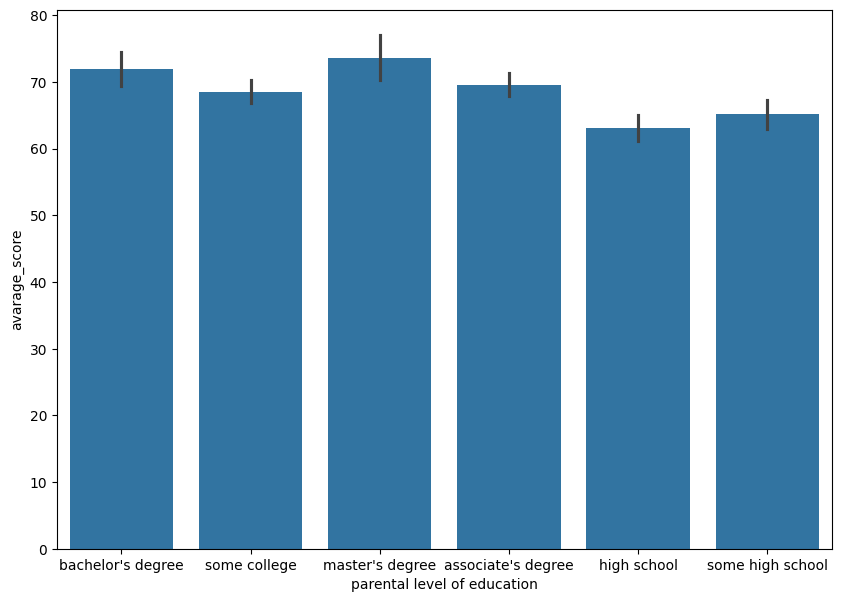

In [33]:
# 45.	barplot: средние оценки по parental level of education.
plt.figure(figsize=(10,7))
sns.barplot(data=df, x='parental level of education', y='avarage_score')
plt.show()

In [34]:
df.head(1)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,avarage_score,3 subjects
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67,218


In [35]:
# 51.	Закодировать категориальные переменные (LabelEncoder или OneHot).
df = pd.get_dummies(df, columns=['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course'], drop_first=True).astype(int)

In [36]:
df.columns

Index(['math score', 'reading score', 'writing score', 'avarage_score',
       '3 subjects', 'gender_male', 'race/ethnicity_group B',
       'race/ethnicity_group C', 'race/ethnicity_group D',
       'race/ethnicity_group E',
       'parental level of education_bachelor's degree',
       'parental level of education_high school',
       'parental level of education_master's degree',
       'parental level of education_some college',
       'parental level of education_some high school', 'lunch_standard',
       'test preparation course_none'],
      dtype='object')

In [37]:
#52.	Нормализовать числовые признаки (StandardScaler).
scaler = StandardScaler()
features = df.drop(columns=['writing score'])
scaled_data = scaler.fit_transform(features)

In [38]:
# 54.	Разделить X и y (y = math score).
x = scaled_data
y = df['writing score']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [39]:
# 56.	Построить LinearRegression() модель.
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [40]:
y_predict = model.predict(x_test)
r2_score(y_predict, y_test)

1.0

In [41]:
joblib.dump(model, 'model_StudentsPerformance.pkl')
joblib.dump(scaler, 'scaler_StudentsPerformance.pkl')

['scaler_StudentsPerformance.pkl']

In [42]:
df.columns

Index(['math score', 'reading score', 'writing score', 'avarage_score',
       '3 subjects', 'gender_male', 'race/ethnicity_group B',
       'race/ethnicity_group C', 'race/ethnicity_group D',
       'race/ethnicity_group E',
       'parental level of education_bachelor's degree',
       'parental level of education_high school',
       'parental level of education_master's degree',
       'parental level of education_some college',
       'parental level of education_some high school', 'lunch_standard',
       'test preparation course_none'],
      dtype='object')